In [1]:
import os
print("Current working directory:", os.getcwd())
print("Does ../src exist from here?", os.path.exists("../src"))
print("Does ../src/features.py exist?", os.path.exists("../src/features.py"))

Current working directory: /home/yon/churn_project/notebooks
Does ../src exist from here? True
Does ../src/features.py exist? True


In [2]:
import sys
import importlib
sys.path.append("../src")

import pandas as pd
import numpy as np
import features
importlib.reload(features)
from features import engineer_features, validate_new_features, run_full_pipeline, load_target

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = load_target("../data/processed/y_train.csv")
y_test  = load_target("../data/processed/y_test.csv")

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)
X_train.head()

X_train: (5634, 20) | X_test: (1409, 20)
y_train: (5634,) | y_test: (1409,)


,Unnamed: 0,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,charges_per_month
0,3738,Male,0,No,No,35.0,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,48.618571
1,3151,Male,0,Yes,Yes,15.0,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,76.770000
2,4860,Male,0,Yes,Yes,13.0,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,45.411538
3,3867,Female,0,Yes,No,26.0,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,73.296154
4,3810,Male,0,Yes,Yes,1.0,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.550000


In [3]:
assert "TotalCharges" not in X_train.columns, "Phase 1 should have dropped this"
assert "charges_per_month" in X_train.columns, "Phase 1 should have engineered this"
assert X_train.isna().sum().sum() == 0, "Phase 1's KNN imputer should have left no NaNs"
print("Phase 1 handoff looks correct.")

Phase 1 handoff looks correct.


In [4]:
categorical_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
for col in categorical_cols:
    print(f"{col}: {X_train[col].unique()}")

gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Partner: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Contract: <StringArray>
['Month-to-month', 'Two year', '

In [5]:
train_engineered = engineer_features(X_train)
new_cols = ["num_services", "is_senior_with_no_support", "cost_per_service"]
train_engineered[new_cols].describe()

,num_services,is_senior_with_no_support,cost_per_service
count,5634.000000,5634.000000,5634.000000
mean,2.058040,0.126021,25.341250
std,1.854652,0.331902,13.845685
min,0.000000,0.000000,8.650000
25%,0.000000,0.000000,17.988542
50%,2.000000,0.000000,20.650000
75%,3.000000,0.000000,27.325000
max,6.000000,1.000000,77.900000


In [6]:
validation_report = validate_new_features(train_engineered, y_train)
print(validation_report.to_string(index=False))
print(train_engineered[["SeniorCitizen", "is_senior_with_no_support"]].corr())

                  feature  n_total  n_flagged  flag_rate  churn_rate_flagged  churn_rate_not_flagged  base_rate  lift_ratio_flagged_vs_not_flagged  lift_pct_vs_base
is_senior_with_no_support     5634        710   0.126021            0.471831                0.235581   0.265353                           2.002841         77.812426
                           SeniorCitizen  is_senior_with_no_support
SeniorCitizen                    1.00000                    0.85955
is_senior_with_no_support        0.85955                    1.00000


In [7]:
pipe = run_full_pipeline()
X_train_transformed = pipe.fit_transform(X_train)   # fit happens ONLY here
X_test_transformed  = pipe.transform(X_test)         # test never re-fits

feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
print("Train:", X_train_transformed.shape, "Test:", X_test_transformed.shape)

Train: (5634, 28) Test: (1409, 28)


In [8]:
assert not np.isnan(X_train_transformed).any(), "Unexpected NaNs after encoding"
assert not np.isnan(X_test_transformed).any(), "Unexpected NaNs after encoding"
assert X_train_transformed.shape[1] == X_test_transformed.shape[1], "Column mismatch train vs test"
print("All checks passed:", X_train_transformed.shape[1], "features")

All checks passed: 28 features


In [9]:
X_train_out = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_out  = pd.DataFrame(X_test_transformed, columns=feature_names)

X_train_out.to_csv("../data/processed/X_train_encoded.csv", index=False)
X_test_out.to_csv("../data/processed/X_test_encoded.csv", index=False)
print("Saved:", X_train_out.shape, X_test_out.shape)

Saved: (5634, 28) (1409, 28)


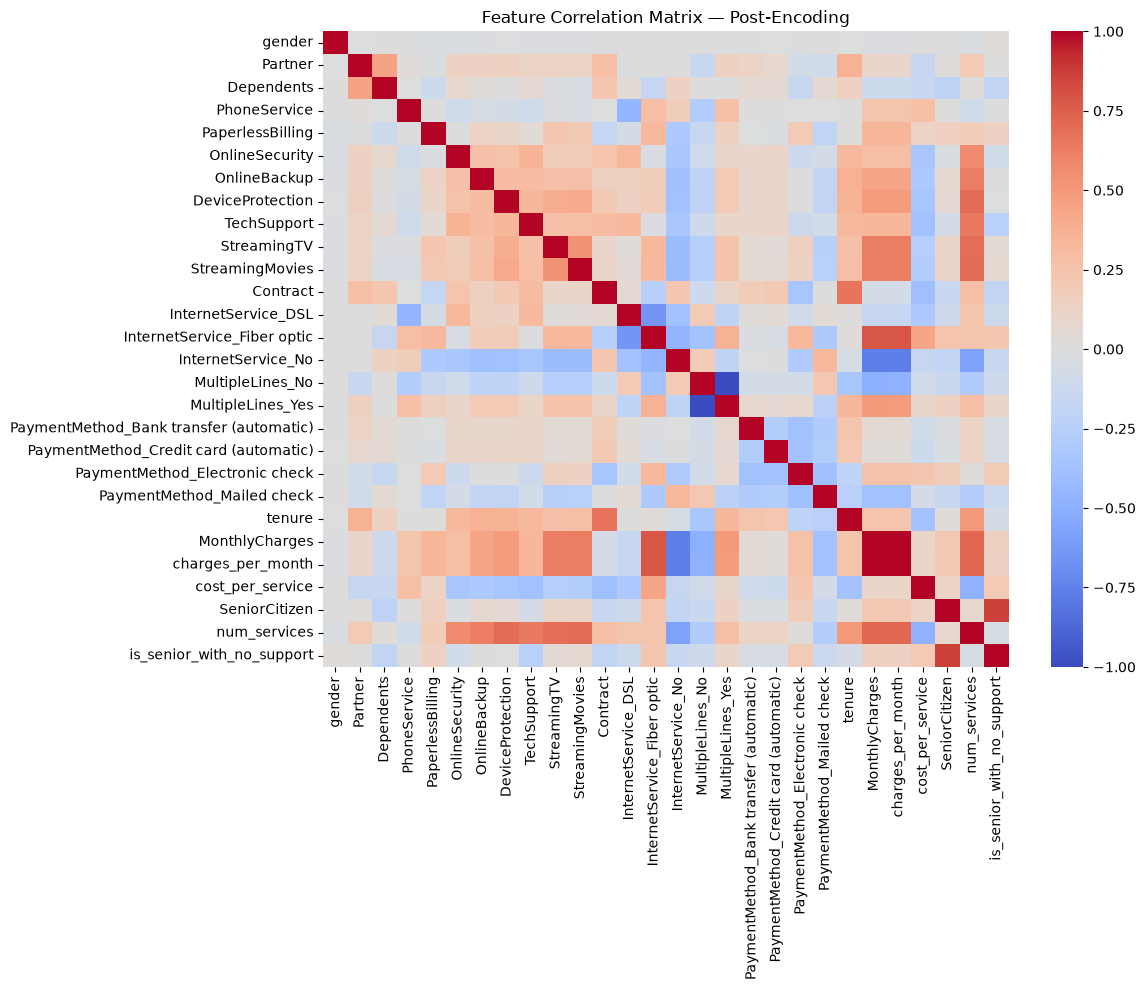

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = X_train_out.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlation Matrix — Post-Encoding")
plt.tight_layout()
plt.savefig("../reports/figures/07_feature_correlations.png", dpi=150)
plt.show()

In [11]:
print("=== Phase 2 Checkpoint ===")
print(f"Input columns:  {X_train.shape[1]}")
print(f"Output columns: {X_train_out.shape[1]}")
print(f"Files written:")
print("  - data/processed/X_train_encoded.csv")
print("  - data/processed/X_test_encoded.csv")
print("  - reports/figures/07_feature_correlations.png")
print(f"New feature validation: see validation_report above — "
      f"confirm before finalizing feature_report.md")

=== Phase 2 Checkpoint ===
Input columns:  20
Output columns: 28
Files written:
  - data/processed/X_train_encoded.csv
  - data/processed/X_test_encoded.csv
  - reports/figures/07_feature_correlations.png
New feature validation: see validation_report above — confirm before finalizing feature_report.md
